In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.head())
print(df.columns)
print(df.isnull().sum())
print(df.describe())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['week'] = df['Date'].dt.isocalendar().week

print(df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday  year  month  day  week
0      1     1 2010-02-05      24924.50      False  2010      2    5     5
1      1     1 2010-02-12      46039.49       True  2010      2   12     6
2      1     1 2010-02-19      41595.55      False  2010      2   19     7
3      1     1 2010-02-26      19403.54      False  2010      2   26     8
4      1     1 2010-03-05      21827.90      False  2010      3    5     9


# EDA

## 1.Sales Trend Over Time

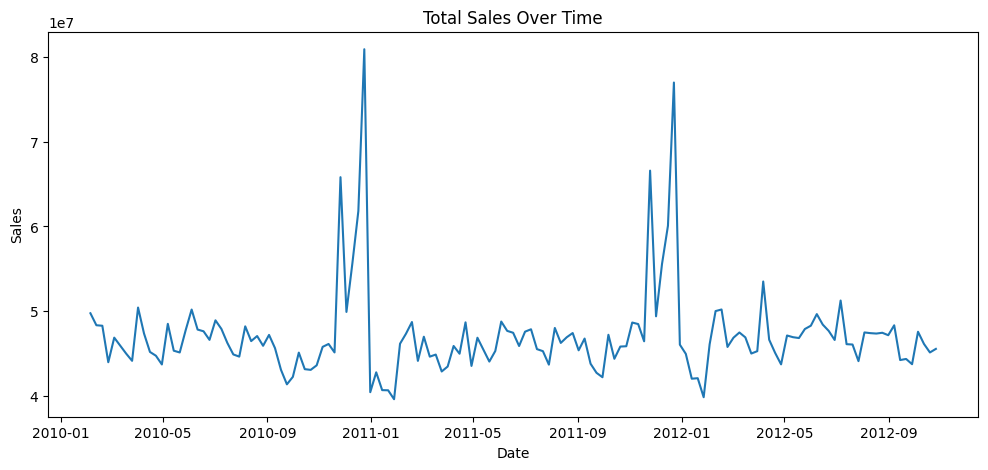

In [4]:
import matplotlib.pyplot as plt

# Group by date
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_trend)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 2.Sales by Store

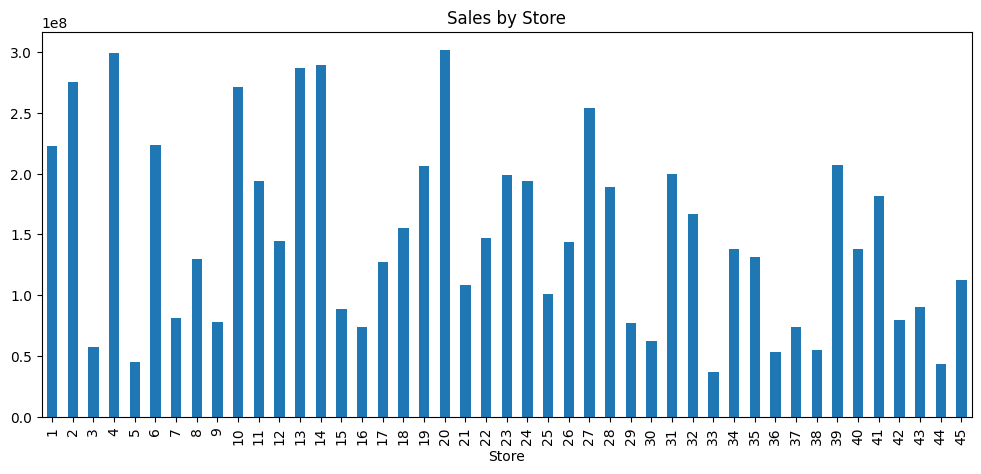

In [5]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

store_sales.plot(kind='bar', figsize=(12,5))
plt.title("Sales by Store")
plt.show()

## 3.Holiday Impact

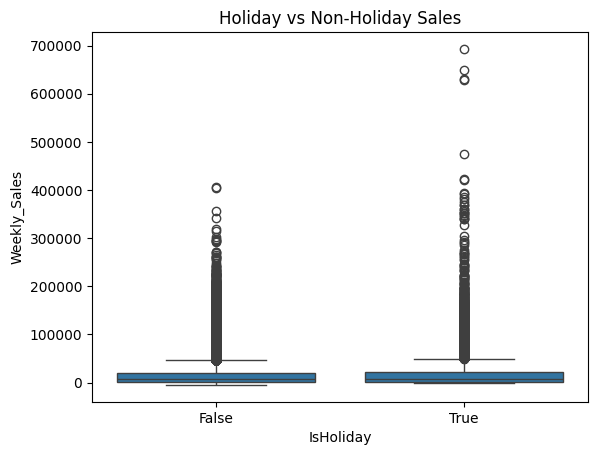

In [6]:
import seaborn as sns

sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

## 4.Monthly Trends

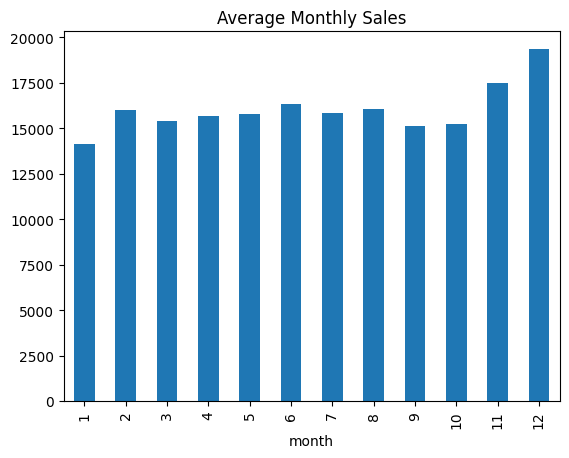

In [7]:
monthly_sales = df.groupby('month')['Weekly_Sales'].mean()

monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()

# Feature Engineering

In [17]:
# Step 1: Sort Data

df = df.sort_values(by=['Store', 'Dept', 'Date'])

In [18]:
# Step 2: Create Lag Features

# Previous week sales
df['lag_1'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

# Previous 4 weeks sales
df['lag_4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)

# Previous 12 weeks sales
df['lag_12'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(12)

In [19]:
# Step 3: Rolling Mean

df['rolling_mean_4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(window=4).mean())

In [20]:
print("Before:", len(df))

Before: 382955


In [21]:
# Step 4: Handle Missing Values

df = df.dropna()

In [22]:
df = df.dropna()
print("After:", len(df))

After: 345774


In [14]:
# check data

print(df.head())

    Store  Dept       Date  Weekly_Sales  IsHoliday  year  month  day  week  \
12      1     1 2010-04-30      16555.11      False  2010      4   30    17   
13      1     1 2010-05-07      17413.94      False  2010      5    7    18   
14      1     1 2010-05-14      18926.74      False  2010      5   14    19   
15      1     1 2010-05-21      14773.04      False  2010      5   21    20   
16      1     1 2010-05-28      15580.43      False  2010      5   28    21   

       lag_1     lag_4    lag_12  rolling_mean_4  
12  16145.35  57258.43  24924.50      33490.4125  
13  16555.11  42960.91  46039.49      23314.5825  
14  17413.94  17596.96  41595.55      16927.8400  
15  18926.74  16145.35  19403.54      17260.2850  
16  14773.04  16555.11  21827.90      16917.2075  


# Model Building (XGboost)

In [24]:
# Step 1: Prepare Features & Target

X = df.drop(['Weekly_Sales', 'Date'], axis=1)
y = df['Weekly_Sales']

In [26]:
# Step 2: Train-Test Split

train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [27]:
# Step 3: Train XGBoost Model

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
# Step 4: Predictions + Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1196.0029428024757
RMSE: 3485.344111035939


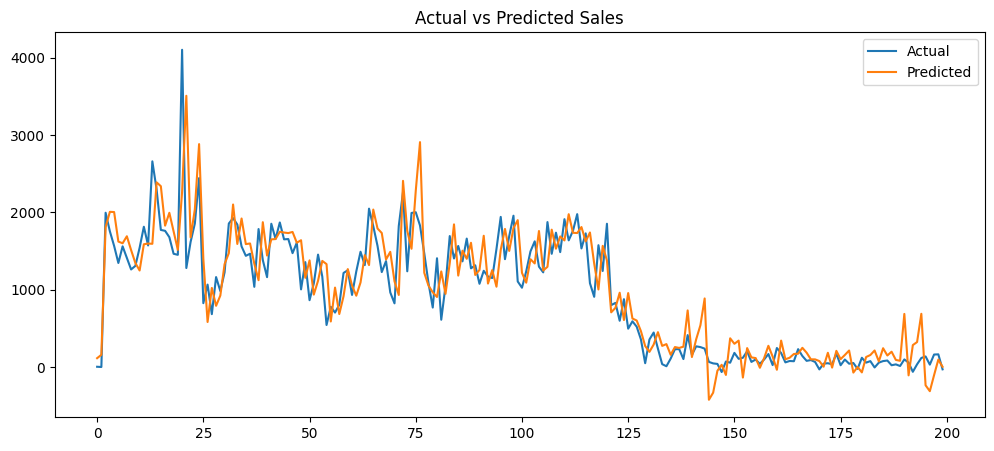

In [29]:
# Step 5: Compare Predictions vs Actual

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# MLflow

In [31]:
pip install mlflow


  Using cached mlflow-3.10.1-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.10.1-py3-none-any.whl.metadata (32 kB)
  Using cached mlflow_tracing-3.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-46.0.5-cp38-abi3-win_amd64.whl.metadata (5.7 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached databricks_sdk-0.102.0-py3-none-any.whl.metadata (40 kB)
  Using cached fastapi-0.135.1-py3-none-any.whl.metadata (30 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached opentelemetry_api-1.40.0-py3-none-an

In [36]:
import mlflow

print("Tracking URI:", mlflow.get_tracking_uri())
import mlflow
import mlflow.xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Demand Forecasting")

with mlflow.start_run():

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # লগ parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)

    # লগ metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

    # লগ model
    mlflow.xgboost.log_model(model, "model")

    print("MAE:", mae)
    print("RMSE:", rmse)

2026/03/19 16:02:13 INFO mlflow.tracking.fluent: Experiment with name 'Demand Forecasting' does not exist. Creating a new experiment.


Tracking URI: sqlite:///C:/Users/Sriram/3D%20Objects/project%202/project/mlflow.db


2026/03/19 16:02:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE: 1196.0029428024757
RMSE: 3485.344111035939
🏃 View run beautiful-gull-914 at: http://127.0.0.1:5000/#/experiments/1/runs/8c61fa67af1e4065a07e8df8de0f3549
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [37]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.


In [38]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']